In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
display(df.shape)
df.info()
df.head(20)

(2443651, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
5,6,B09B97WSLF,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
6,7,B09B9615X2,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
7,8,B01MTB55WH,Anker Soundcore 2 Portable Bluetooth Speaker w...,4.7,103673,39.99,False,0,Hi-Fi Speakers
8,9,B016MO90GW,"Bluetooth Speaker, Anker Soundcore Speaker Upg...",4.7,29909,29.99,False,0,Hi-Fi Speakers
9,10,B09ZQF5GZW,RIENOK Bluetooth Speaker Portable Wireless Blu...,4.5,16014,29.99,False,0,Hi-Fi Speakers


In [3]:
display(df["category"].nunique())

print()

df["category"].unique()

296

array(['Hi-Fi Speakers', 'CD, Disc & Tape Players', 'Wearable Technology',
       'Light Bulbs', 'Bathroom Lighting',
       'Heating, Cooling & Air Quality', 'Coffee & Espresso Machines',
       'Lab & Scientific Products', 'Smart Speakers',
       'Motorbike Clothing', 'Motorbike Accessories',
       'Motorbike Batteries', 'Motorbike Boots & Luggage',
       'Motorbike Chassis', 'Handmade Home & Kitchen Products',
       'Hardware', 'Storage & Home Organisation',
       'Fireplaces, Stoves & Accessories', 'PC Gaming Accessories',
       'USB Gadgets', 'Blank Media Cases & Wallets', 'Car & Motorbike',
       'Boys', 'Sports & Outdoors', 'Microphones', 'String Instruments',
       'Karaoke Equipment', 'PA & Stage',
       'General Music-Making Accessories', 'Wind Instruments',
       'Handmade Gifts', 'Fragrances', 'Calendars & Personal Organisers',
       'Furniture & Lighting', 'Computer Printers', 'Ski Goggles',
       'Snowboards', 'Skiing Poles', 'Downhill Ski Boots',
       'Hiki

In [7]:
df_bestsellers = df.query("isBestSeller == True and boughtInLastMonth > 0").sort_values(by= "boughtInLastMonth" , ascending=False)
display(df_bestsellers.shape)
df_bestsellers.info()
df_bestsellers.head(20)

(5416, 9)

<class 'pandas.core.frame.DataFrame'>
Index: 5416 entries, 1661254 to 646237
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   uid                5416 non-null   int64  
 1   asin               5416 non-null   object 
 2   title              5416 non-null   object 
 3   stars              5416 non-null   float64
 4   reviews            5416 non-null   int64  
 5   price              5416 non-null   float64
 6   isBestSeller       5416 non-null   bool   
 7   boughtInLastMonth  5416 non-null   int64  
 8   category           5416 non-null   object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 386.1+ KB


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
1661254,1868356,B001MZV3OO,Catsan Hygiene Cat Litter 20L,4.7,29066,14.00,True,50000,Grocery
1661255,1868357,B01JS6YLQK,"Regina Blitz Household Towel, 560 Super-Sized ...",4.8,40648,14.99,True,30000,Grocery
208323,222678,B00BSYR7K8,"Earth Rated Dog Poo Bags, New Look, Guaranteed...",4.7,129459,13.74,True,20000,Pet Supplies
2222929,2569869,B086KDW3W5,"Mr Muscle Drain Unblocker, Sink & Drain Cleane...",4.5,22780,6.00,True,20000,Baby
2196565,2542559,B07CD8N63G,Nature Spell Rosemary Oil for Hair & Skin 150m...,4.5,3732,7.98,True,20000,Hair Care
1318323,1456362,B001ETUD5I,"Nizoral Anti-dandruff Shampoo, Treats and Prev...",4.6,27110,6.82,True,20000,Health & Personal Care
1290025,1426480,B00IIOR7NS,Zero In Spider Repellent – 500 ml. Ready-to-us...,3.9,9001,5.90,True,20000,Gardening
1318324,1456363,B004RDYI04,"Sudafed Blocked Nose Spray, Relief from Conges...",4.7,14689,4.00,True,20000,Health & Personal Care
1318325,1456364,B0BH8SHD38,Step Ahead Covid-19 Lateral Flow Testing Kit |...,4.4,2833,6.95,True,20000,Health & Personal Care
1090598,1204924,B0080ZSQKS,Dr.Beckmann Service-it Deep Clean Washing Mach...,4.4,15426,2.40,True,20000,Large Appliances


In [8]:
# 1. **Frequency Tables**: Generate a frequency table for the product `category`. Which are the top 5 most listed product categories?

freq_table =pd.crosstab(index=df["category"], columns = "count")
freq_table = freq_table.sort_values(by='count', ascending=False)
display(freq_table)

col_0,count
category,
Sports & Outdoors,836265
Beauty,19312
"Handmade Clothing, Shoes & Accessories",19229
Bath & Body,19092
Birthday Gifts,18978
...,...
Motorbike Chassis,107
Plugs,107
Alexa Built-In Devices,107


In [39]:
#crosstable with prices and frequency for later

freq_table_prices =pd.crosstab(index=df["price"], columns = "count")
freq_table_prices = freq_table_prices.sort_values(by='count', ascending=False)
display(freq_table_prices)


col_0,count
price,
9.99,48922
12.99,38823
8.99,34058
7.99,33632
14.99,32570
...,...
740.12,1
740.15,1
740.17,1


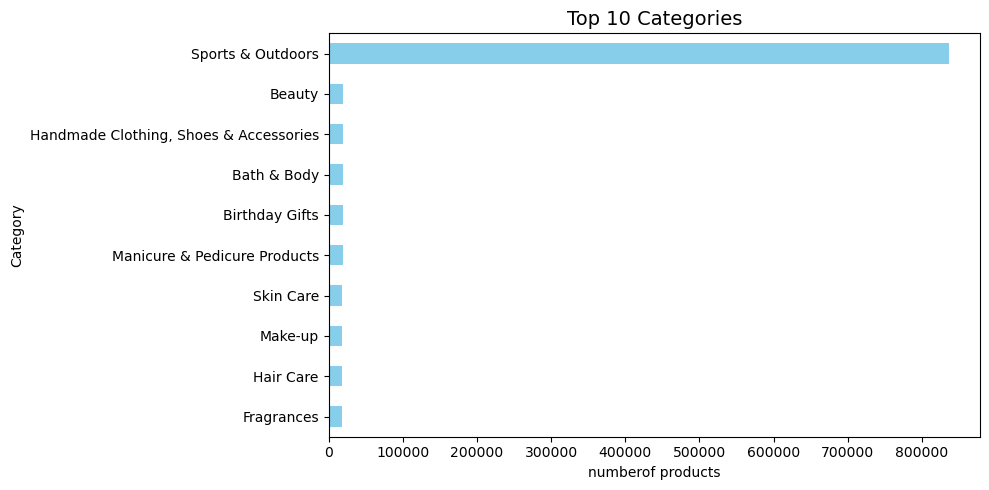

In [27]:
# Visualizations: Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
#For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

top10 = freq_table.head(10)

top10.plot(kind="barh", figsize=(10, 5), color="skyblue", legend=False)

plt.gca().invert_yaxis()

plt.title("Top 10 Categories", fontsize=14)
plt.xlabel("numberof products")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

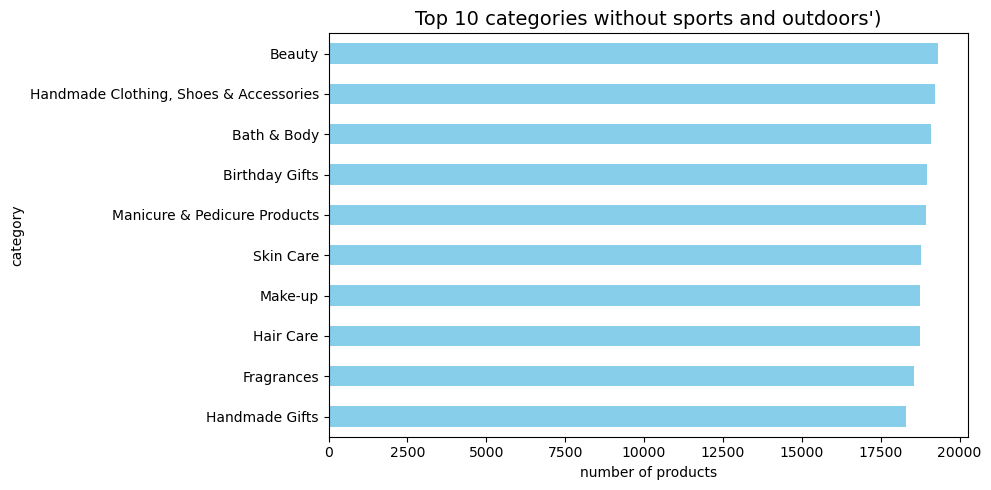

In [28]:
top10_without_first_one = freq_table.iloc[1:11]

top10_without_first_one.plot(kind="barh", figsize=(10, 5), color="skyblue", legend=False)

plt.gca().invert_yaxis()

plt.title("Top 10 categories without sports and outdoors')", fontsize=14)
plt.xlabel("number of products")
plt.ylabel("category")

plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

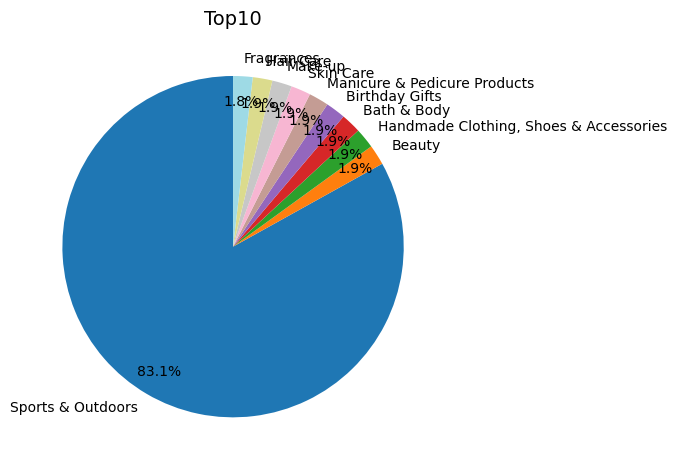

In [32]:
top10_c = freq_table.head(10)

plt.figure(figsize=(8, 8))
top10_c.plot(
    pctdistance=0.85,
    kind="pie",
    y="count",
    autopct="%1.1f%%",
    startangle=90,
    legend=False,
    cmap="tab20",
)

plt.title("Top10", fontsize=14)
plt.ylabel("")  
plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

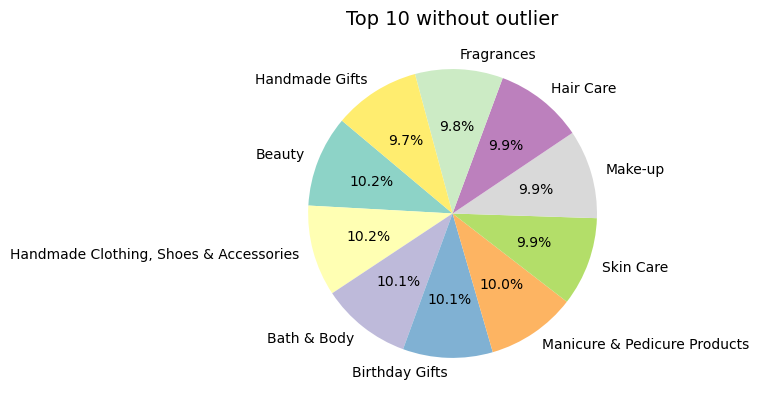

In [33]:
top10_without_outlier = freq_table.iloc[1:11]

plt.figure(figsize=(8, 8))
top10_without_outlier.plot(
    kind="pie",
    y="count",
    autopct="%1.1f%%",
    startangle=140,
    legend=False,
    cmap="Set3",
)

plt.title(
    "Top 10 without outlier", fontsize=14
)
plt.ylabel("")  
plt.tight_layout()
plt.show()

In [70]:
def colum_values_lower(df):
    for col in df.select_dtypes(include=['category']).columns:
        df[col] = df[col].str.lower().str.strip()
    return df
colum_values_lower(df)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


## Part 2: Delving into Product Pricing

### Measures of Centrality:

In [34]:
# Calculate the mean, median, and mode for the price of products.

mean_price = df["price"].mean()
median_price = df["price"].median()
mode_price = df["price"].mode()[0]

mean_price, median_price, mode_price

(np.float64(89.24380943923661), 19.09, np.float64(9.99))

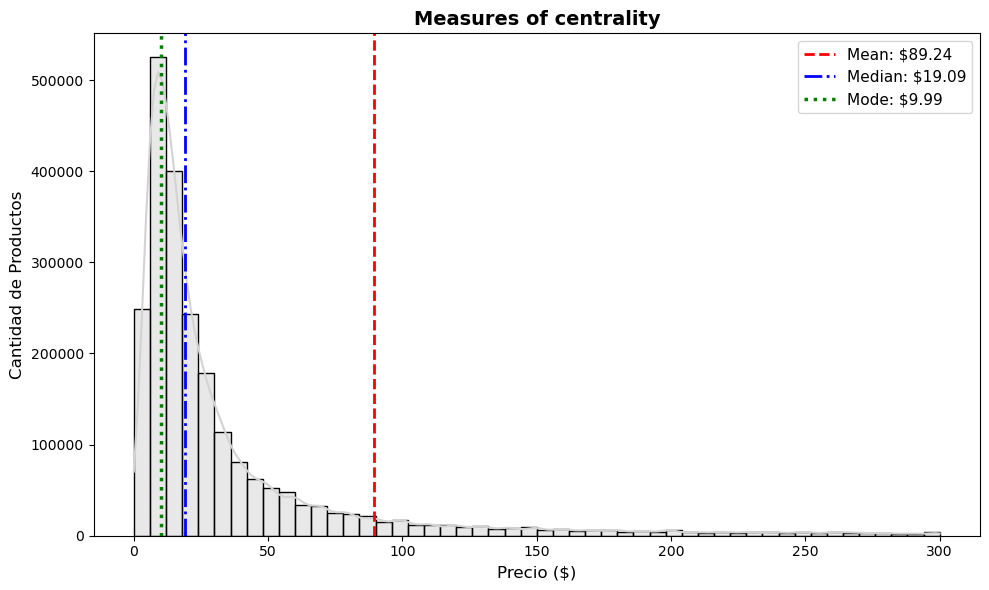

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(df.query("price < 300")["price"], kde=True, color="lightgray", bins=50)

plt.axvline(mean_price, color="red", linestyle="dashed", linewidth=2, label=f"Mean: ${mean_price:.2f}")
plt.axvline(median_price, color="blue", linestyle="dashdot", linewidth=2, label=f"Median: ${median_price:.2f}",)
plt.axvline( mode_price, color="green", linestyle="dotted", linewidth=2.5, label=f"Mode: ${mode_price:.2f}",)

plt.title( "Measures of centrality", fontsize=14, fontweight="bold",)
plt.xlabel("Precio ($)", fontsize=12)
plt.ylabel("Cantidad de Productos", fontsize=12)

plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..

I'm using bins to get the analysis clearly and readable

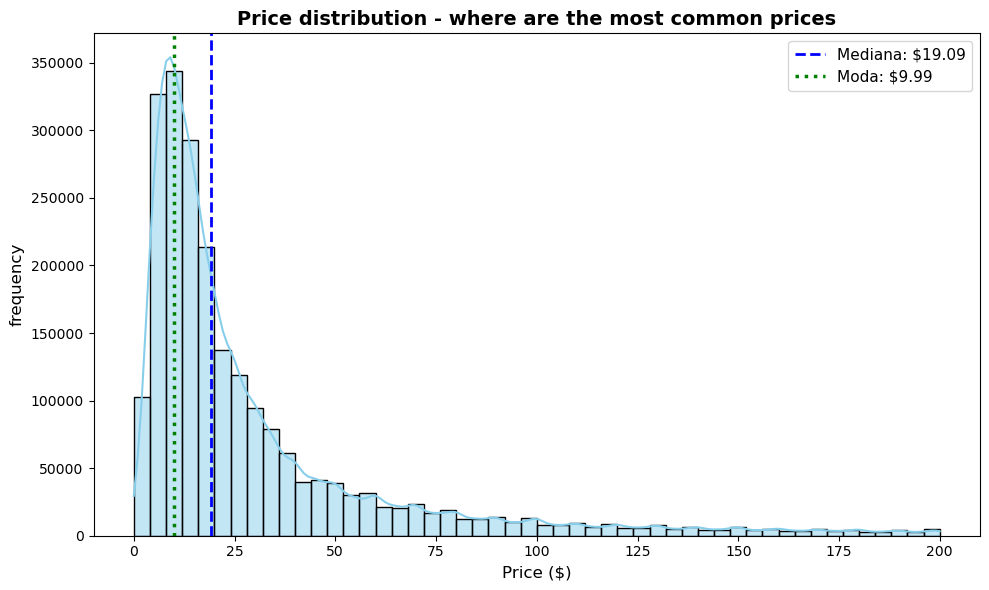

In [38]:
plt.figure(figsize=(10, 6))

sns.histplot( df.query("price < 200")["price"], bins=50, kde=True, color="skyblue")

plt.axvline( 19.09, color="blue", linestyle="dashed", linewidth=2, label="Mediana: $19.09")
plt.axvline( 9.99, color="green", linestyle="dotted", linewidth=2.5, label="Moda: $9.99")
plt.title( "Price distribution - where are the most common prices", fontsize=14, fontweight="bold")
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("frequency", fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [43]:
df_price_frec = freq_table_prices.reset_index()

df_price_frec.columns = ["price", "number_of_products"]

display(df_price_frec)

,price,number_of_products
0,9.99,48922
1,12.99,38823
2,8.99,34058
3,7.99,33632
4,14.99,32570
...,...,...
82911,740.12,1
82912,740.15,1
82913,740.17,1
82914,740.23,1


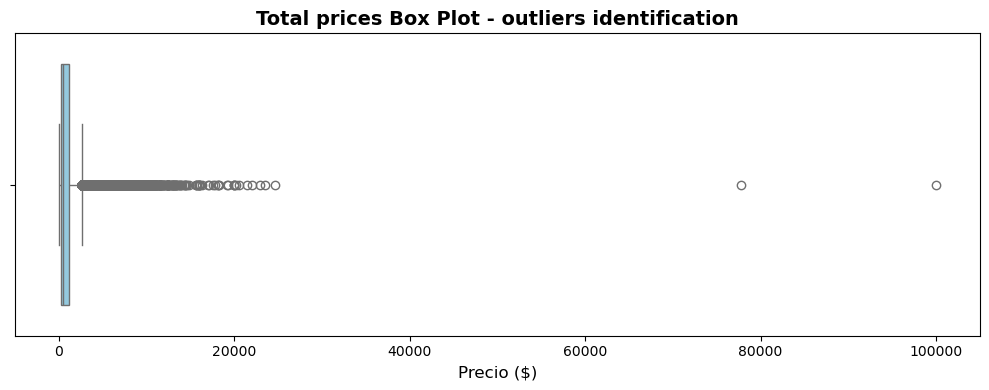

In [45]:
#boxplot to see outliers

plt.figure(figsize=(10, 4))

sns.boxplot(data=df_price_frec, x="price", color="skyblue")

plt.title(
    "Total prices Box Plot - outliers identification",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Precio ($)", fontsize=12)

plt.tight_layout()
plt.show()

# Part 3: Unpacking Product Ratings


In [ ]:
# Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

In [57]:
freq_stars =pd.crosstab(index=df["stars"], columns = "count")
freq_stars = freq_stars.sort_values(by='count', ascending=False)
df_stars = freq_stars.reset_index()

df_stars.columns = ["stars", "number_of_products"]

display(df_stars)

,stars,number_of_products
0,0.0,1225641
1,4.5,151577
2,4.6,136995
3,4.4,136165
4,5.0,128492
5,4.3,112564
6,4.7,94566
7,4.2,86871
8,4.0,66089
9,4.1,65115


In [56]:
#Measures of Centrality:

mean_rating = df_stars["stars"].mean()
median_rating = df_stars["stars"].median()
mode_rating = df_stars["stars"].mode()[0]

mean_rating, median_rating, mode_rating

(np.float64(2.9285714285714284), 2.95, np.float64(0.0))

In [ ]:
# the tendency is to NOT rate the products

### Measures of Dispersion:

In [58]:
#variance, standard deviation, and interquartile range for product rating

df_stars.describe()

,stars,number_of_products
count,42.000000,4.200000e+01
mean,2.928571,5.818217e+04
std,1.270545,1.899940e+05
min,0.000000,3.000000e+00
25%,1.925000,6.350000e+02
50%,2.950000,7.020000e+03
75%,3.975000,4.053225e+04
max,5.000000,1.225641e+06


In [ ]:
# Are the ratings normally distributed, or do they lean towards higher or lower values? --> normally distributed, leaning to the higher values (4,5)

In [ ]:
#Plot a histogram to visualize the distribution of product ratings

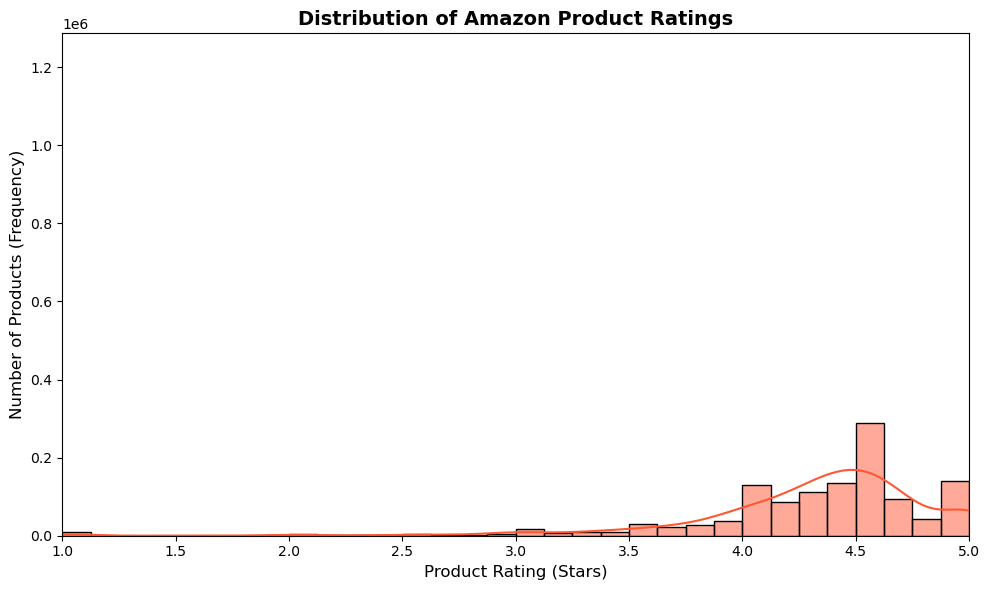

In [67]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="stars", bins=40, kde=True, color ="#FF5733")

plt.xlim(1, 5)

plt.title(
    "Distribution of Amazon Product Ratings", fontsize=14, fontweight="bold"
)
plt.xlabel("Product Rating (Stars)", fontsize=12)
plt.ylabel("Number of Products (Frequency)", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

# The most noticeable category is "sports and ourdoors" by far (with a listing frequency of 836,265 products), followed by "Beauty", "Handmade Clothing, Shoes & Accessories"

# Beauty, the second most popular category, cant compete with "sports and outdoors" since it has more than 40 times the frequency.

# The second most frequent category, "Beauty" (19,312 listings), holds less than 2.5% of the volume of the leader. However, when excluding "Sports & Outdoors", the rest of the Top 10 categories (such as Handmade Clothing, Bath & Body, and Birthday Gifts) compare very evenly against each other, maintaining a consistent frequency of around 18,000 to 19,000 listings each.